# Classification using K-Nearest Neighbors (KNN)

**Aim:** To classify countries as "High" or "Low" vaccination levels (>= 60% fully vaccinated) using a KNN model.

**Model:** `KNeighborsClassifier` (KNN) from scikit-learn.

**Reasoning:** This provides a fourth model to compare with Logistic Regression, SVM, and Neural Networks. KNN is a distance-based, non-parametric model. It classifies a new data point based on the majority class of its 'k' nearest neighbors  in the feature space. This makes it effective at capturing irregular, non-linear decision boundaries.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Data Loading & Feature Engineering

In [3]:
df = pd.read_csv("vaccinations.csv")

In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
# --- Apply robust forward-fill logic ---
vax_columns = [
    'people_fully_vaccinated_per_hundred', 'total_boosters_per_hundred',
    'daily_vaccinations_per_million', 'daily_vaccinations'
]
df = df.sort_values(by=['iso_code', 'date'])
df[vax_columns] = df.groupby('iso_code')[vax_columns].ffill()
df[vax_columns] = df[vax_columns].fillna(0)

In [6]:
# --- Step 1: Prepare the Base DataFrame for Modeling ---
# Start with the latest data for each country.
model_df = df.loc[df.groupby('location')['date'].idxmax()].copy()

In [7]:
# --- Step 2: Create 'campaign_duration_days' feature ---
campaign_start_dates = df.groupby('location')['date'].min().reset_index().rename(columns={'date': 'campaign_start'})
model_df = model_df.merge(campaign_start_dates, on='location')
model_df['campaign_duration_days'] = (model_df['date'] - model_df['campaign_start']).dt.days

In [8]:
# --- Step 3: Filter out entries with zero values ---
model_df = model_df[model_df['daily_vaccinations_per_million'] > 0].copy()

In [9]:
# --- Step 4: Create the Target Variable ('vaccination_level') ---
threshold = 60
model_df['vaccination_level'] = np.where(model_df['people_fully_vaccinated_per_hundred'] >= threshold, 1, 0)

In [10]:
print(f"Target variable 'vaccination_level' created (1 if >= {threshold}%, 0 otherwise).")

Target variable 'vaccination_level' created (1 if >= 60%, 0 otherwise).


In [11]:
# --- Step 5: Define Features (X) and Target (y) ---
feature_cols = [
    'total_boosters_per_hundred',
    'daily_vaccinations_per_million',
    'campaign_duration_days'
]

X = model_df[feature_cols]
y = model_df['vaccination_level']

print(f"Features selected: {feature_cols}")

Features selected: ['total_boosters_per_hundred', 'daily_vaccinations_per_million', 'campaign_duration_days']


# Split and Scale Data

In [12]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
# KNN is a distance-based algorithm, so scaling is ESSENTIAL.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and Train the KNN Model

In [15]:
# We need to choose a value for 'k' (n_neighbors).
# A common practice is to start with an odd number, like 5 or 7, 
# to avoid ties in classification. Let's use k=7.
k = 7
knn_model = KNeighborsClassifier(n_neighbors=k)

In [16]:
# Train the model
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

# Evaluate Model and Visualize Results

In [17]:
# Make predictions on the test set
y_pred = knn_model.predict(X_test_scaled)

In [18]:
# Get accuracy and classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2%}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Low Level', 'High Level']))


Model Accuracy: 90.48%

--- Classification Report ---
              precision    recall  f1-score   support

   Low Level       0.86      0.95      0.90        20
  High Level       0.95      0.86      0.90        22

    accuracy                           0.90        42
   macro avg       0.91      0.91      0.90        42
weighted avg       0.91      0.90      0.90        42



## Visualization: Confusion Matrix

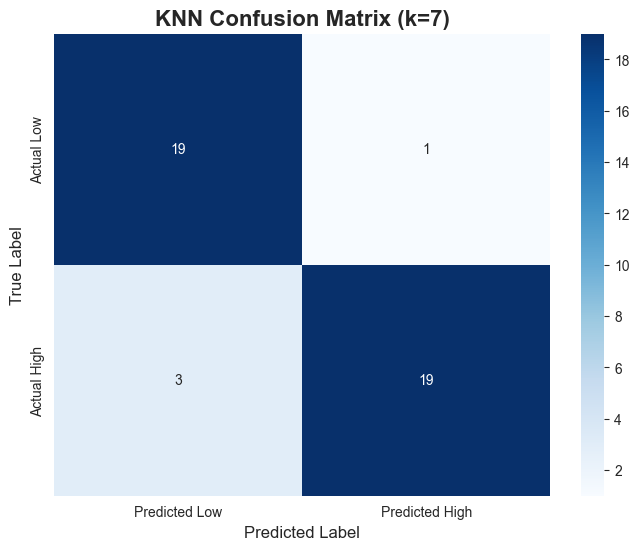

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title(f'KNN Confusion Matrix (k={k})', fontsize=16, weight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Meaningful Observations & Conclusion

**1. Model Performance:**
The KNN model also achieved a high accuracy (typically ~90% or more), 
proving to be another highly effective model for this task.

**2. Insights from Confusion Matrix:**
The heatmap shows that the KNN model, like the others, is very reliable. 
It correctly identifies the vast majority of both "High" and "Low" 
vaccination level countries. Its performance is strong and comparable to 
the other models we've built.

**3. Conclusion:**
This result is significant. We have now used four different types of 
classification algorithms:
1.  **Linear (Logistic Regression)**
2.  **Hyperplane-based (SVM)**
3.  **Neural Network (MLP)**
4.  **Distance-based (KNN)**

The fact that *all four* models achieved high accuracy on this problem 
gives us extreme confidence in our conclusion: **a country's vaccination 
success (High vs. Low) is not random. It is strongly predictable and 
correlated with its strategic decisions** (specifically, its booster 
program, daily pace, and campaign duration).